# Layer Efficiency - Greedy Layer Selection for DINO-Based ViTs

## Introduction

In this notebook, we perform a detailed, layer-wise evaluation of two self-supervised Vision Transformer (ViT) models trained using DINO: ViT-S/16 and ViT-B/8. The goal is to analyze how much each transformer block contributes to the final classification accuracy when using linear probing on frozen representations.

To this end, we implement a greedy layer selection strategy. Starting with an empty model, we iteratively select the layer that provides the greatest accuracy gain when added. This allows us to quantify which layers are most essential for downstream performance and to determine the minimum number of layers required to reach a target accuracy (e.g., 90%).

We visualize accuracy progression, cumulative gains, and identify performance bottlenecks. Additionally, we compare both models side by side to understand differences in layer utility, redundancy, and efficiency.

Key insights include:
- How quickly each model approaches peak accuracy.
- The minimal layer subset required for competitive performance.
- Differences in representational capacity between ViT-S/16 and ViT-B/8.

This analysis can guide efficient model deployment by identifying layers that can be pruned or emphasized in downstream tasks.


In [1]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms
from timm import create_model
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from metrics.CKA import linear_CKA
from metrics.CKNNA import AlignmentMetrics
from script import collect_outputs_with_skipping

c:\Users\olenk\PWProjects\WB_2_Project\VisualLogitLens\dino_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Please install the pymp library using `pip install pymp` to speed up non-batched metrics


In [ ]:
def greedy_layer_selection(model, dataloader, linear_classifier, target_acc=0.9, max_batches=None):
    '''
    Performs greedy selection of transformer layers based on their contribution to classification accuracy.

    At each iteration, the function adds the layer that provides the highest accuracy improvement
    when combined with already selected layers. The process continues until all layers are evaluated,
    even if the target accuracy is reached earlier.

    Returns a dictionary containing accuracy progression, added layers in order,
    and the number of layers needed to reach the target accuracy.
    '''
    from copy import deepcopy

    max_layer = len(model.blocks)
    selected_layers = []
    remaining_layers = list(range(max_layer))
    acc_progression = []
    added_layers = []

    print("\n[INFO] Starting greedy layer selection...\n")

    while remaining_layers:
        best_acc = -1
        best_layer = None

        for layer in remaining_layers:
            test_layers = selected_layers + [layer]
            skip_layers = [i for i in range(max_layer) if i not in test_layers]
            print(f"[DEBUG] Trying with layers: {test_layers} (skipping {skip_layers})")

            X_val, y_val = collect_outputs_with_skipping(model, dataloader, skip_layers=skip_layers, max_batches=max_batches)
            inputs = torch.tensor(X_val, dtype=torch.float32).to(device)

            with torch.no_grad():
                outputs = linear_classifier(inputs)
                y_pred = outputs.argmax(dim=1).cpu().numpy()

            acc = accuracy_score(y_val, y_pred)
            print(f"    Accuracy with layers {test_layers}: {acc:.4f}")

            if acc > best_acc:
                best_acc = acc
                best_layer = layer

        if best_layer is not None:
            selected_layers.append(best_layer)
            remaining_layers.remove(best_layer)
            acc_progression.append(best_acc)
            added_layers.append(best_layer)
            print(f"\n[INFO] Added layer {best_layer} → current acc: {best_acc:.4f}\n")

    return {
        'selected_layers': selected_layers,
        'accuracy_per_step': acc_progression,
        'added_layers': added_layers,
        'target_acc': target_acc
    }

In [77]:
# Visualization functions

def plot_greedy_progression(result_dict, model_name="ViT"):
    added_layers = result_dict['added_layers']
    accuracies = result_dict['accuracy_per_step']
    target_acc = result_dict['target_acc']

    colors = ['#4b72af' if acc < target_acc else '#bb294b' for acc in accuracies]
    x = list(range(1, len(added_layers) + 1))

    plt.figure(figsize=(12, 6))
    bars = plt.bar(x, accuracies, color=colors)
    plt.axhline(y=target_acc, color='#bb294b', linestyle='--', label=f'Target Accuracy: {target_acc}')
    
    for i, (layer, acc) in enumerate(zip(added_layers, accuracies)):
        plt.text(x[i], acc + 0.005, f"L{layer}", ha='center', va='bottom', fontsize=11, rotation=0)

    plt.title(f"Greedy Layer Selection Progression - {model_name}")
    plt.xlabel("Step (Layer Added)")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.show()


def plot_layer_gain_waterfall(result_dict, model_name="ViT"):
    accs = result_dict['accuracy_per_step']
    gains = np.diff([0] + accs)
    layers = result_dict['added_layers']
    target_acc = result_dict['target_acc']
    
    cumulative = np.cumsum(gains)
    prev = 0

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, (gain, layer) in enumerate(zip(gains, layers)):
        color = '#79bd9f' if gain >= 0 else 'red'
        ax.bar(i, gain, bottom=prev, color=color, edgecolor='none')
        prev += gain
        sign = "+" if gain >= 0 else ""
        ax.text(i, prev + 0.01 if gain >= 0 else prev - 0.01, f"{sign}{gain:.2f}", 
                ha='center', va='bottom' if gain >= 0 else 'top', fontsize=10)


    total_acc = sum(gains)
    final_idx = len(gains)
    ax.bar(final_idx, 0, bottom=0, color='white', edgecolor='none')
    ax.bar(final_idx, total_acc, color='#bb294b', edgecolor='none')
    ax.text(final_idx, total_acc + 0.01, f"{total_acc:.2f}", ha='center', va='bottom', fontsize=10)

    ax.set_xticks(list(range(len(layers))) + [final_idx])
    ax.set_xticklabels([f"L{l}" for l in layers] + ["Total"], rotation=45)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray')

    ax.set_ylabel("Cumulative Accuracy")
    ax.set_title(f"Accuracy Gain per Added Layer - {model_name}")
    plt.axhline(y=target_acc, color='#bb294b', linestyle='--', label=f'Target Accuracy: {target_acc}')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [42]:
SELECTED_CLASSES = ['n01632777', 'n01984695', 'n01728572', 'n01514859',
                    'n01614925', 'n01582220', 'n01806143', 'n01819313']


class SelectedImageNet(Dataset):
    def __init__(self, root_dirs, selected_classes, transform=None):
        self.root_dirs = [root_dirs] if isinstance(root_dirs, str) else root_dirs
        self.selected_classes = selected_classes
        self.transform = transform
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(sorted(list(self.selected_classes)))}
        self.samples = self._find_samples()

    def _find_samples(self):
        samples = []
        for root_dir in self.root_dirs:
            if not os.path.isdir(root_dir):
                print(f"Warning: Directory not found {root_dir}, skipping.")
                continue
            for class_name in os.listdir(root_dir):
                if class_name in self.selected_classes:
                    class_path = os.path.join(root_dir, class_name)
                    if os.path.isdir(class_path):
                        for img_name in os.listdir(class_path):
                            img_path = os.path.join(class_path, img_name)
                            if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                                samples.append((img_path, self.class_to_idx[class_name]))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


val_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


base_train_dir = "..\\data"
train_dirs = [os.path.join(base_train_dir, f"train.X{i}") for i in range(1, 5)]
val_path = os.path.join(base_train_dir, "val.X")

train_dataset = SelectedImageNet(train_dirs, SELECTED_CLASSES, transform=train_transform)
val_dataset = SelectedImageNet(val_path, SELECTED_CLASSES, transform=val_transform)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

#### Model DINO ViT-S/16

In [5]:
class LinearClassifier(nn.Module):
    """Linear layer to train on top of frozen features"""
    def __init__(self, dim, num_labels=1000):
        super(LinearClassifier, self).__init__()
        self.num_labels = num_labels
        self.linear = nn.Linear(dim, num_labels)
        self.linear.weight.data.normal_(mean=0.0, std=0.01)
        self.linear.bias.data.zero_()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embed_dim = 384 
num_labels = 8 

linear_classifier = LinearClassifier(dim=embed_dim, num_labels=num_labels)
linear_classifier.to(device)

checkpoint = torch.load("../linear_probe/best_model_dino_S16.pth", map_location=device)
linear_classifier.load_state_dict(checkpoint['model'])
linear_classifier.eval()

model_S16 = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
model_S16.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_S16.to(device)

Using cache found in C:\Users\olenk/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [8]:
result_S16 = greedy_layer_selection(
    model=model_S16,
    dataloader=val_loader,
    linear_classifier=linear_classifier,
    target_acc=0.9
)


[INFO] Starting greedy layer selection...

[DEBUG] Trying with layers: [0] (skipping [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])


    Accuracy with layers [0]: 0.1425
[DEBUG] Trying with layers: [1] (skipping [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])


    Accuracy with layers [1]: 0.1250
[DEBUG] Trying with layers: [2] (skipping [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11])


    Accuracy with layers [2]: 0.1175
[DEBUG] Trying with layers: [3] (skipping [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11])


    Accuracy with layers [3]: 0.1300
[DEBUG] Trying with layers: [4] (skipping [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11])


...

    Accuracy with layers [5, 0, 11, 3, 1, 8, 7, 9, 2, 6]: 0.9775
[DEBUG] Trying with layers: [5, 0, 11, 3, 1, 8, 7, 9, 2, 10] (skipping [4, 6])


    Accuracy with layers [5, 0, 11, 3, 1, 8, 7, 9, 2, 10]: 0.9675

[INFO] Added layer 6 → current acc: 0.9775

[DEBUG] Trying with layers: [5, 0, 11, 3, 1, 8, 7, 9, 2, 6, 4] (skipping [10])


    Accuracy with layers [5, 0, 11, 3, 1, 8, 7, 9, 2, 6, 4]: 0.9825
[DEBUG] Trying with layers: [5, 0, 11, 3, 1, 8, 7, 9, 2, 6, 10] (skipping [4])


    Accuracy with layers [5, 0, 11, 3, 1, 8, 7, 9, 2, 6, 10]: 0.9800

[INFO] Added layer 4 → current acc: 0.9825

[DEBUG] Trying with layers: [5, 0, 11, 3, 1, 8, 7, 9, 2, 6, 4, 10] (skipping [])


    Accuracy with layers [5, 0, 11, 3, 1, 8, 7, 9, 2, 6, 4, 10]: 0.9850

[INFO] Added layer 10 → current acc: 0.9850



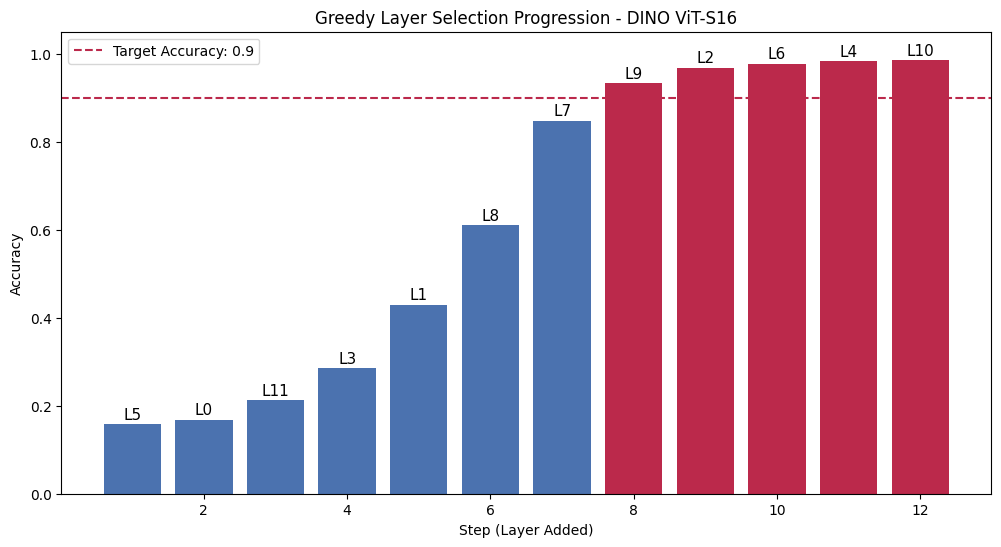

In [43]:
plot_greedy_progression(result_S16, model_name="DINO ViT-S16")

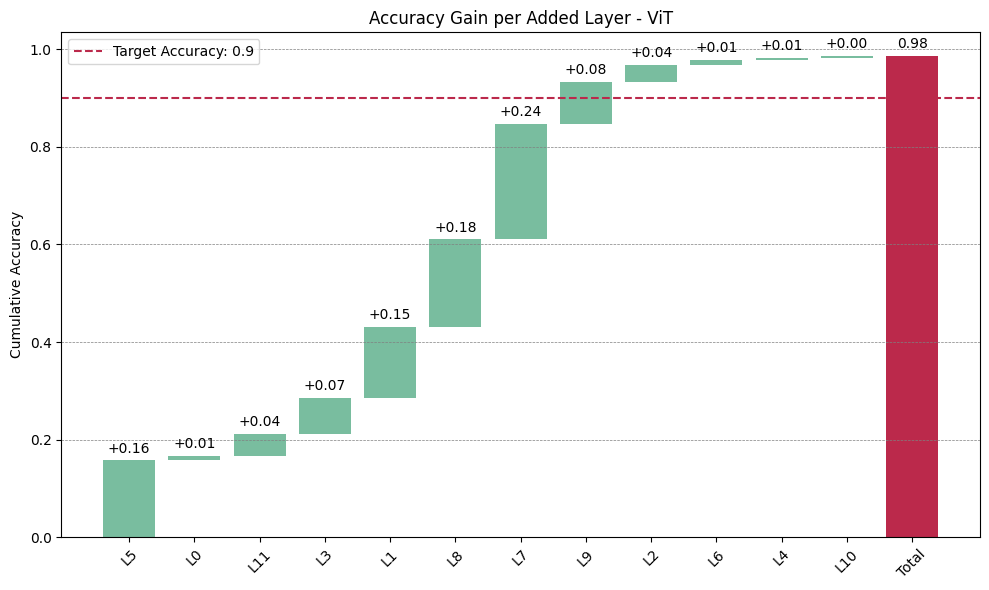

In [ ]:
plot_layer_gain_waterfall(result_S16, model_name="DINO ViT-S16")

In DINO ViT-S16, we observe a gradual increase in accuracy as the initial selected layers are added. The most significant improvements occur in the middle stages of the selection process, with the target accuracy of 0.9 being reached after adding the 8th layer. However, there is no clear or consistent trend in the order of selected layers. Interestingly, the first selected layer is layer 5, followed by layer 0, while the last layers to be added are layers 4 and 10.

#### Model DINO ViT-B/8

In [45]:
class LinearClassifier(nn.Module):
    """Linear layer to train on top of frozen features"""
    def __init__(self, dim, num_labels=1000):
        super(LinearClassifier, self).__init__()
        self.num_labels = num_labels
        self.linear = nn.Linear(dim, num_labels)
        self.linear.weight.data.normal_(mean=0.0, std=0.01)
        self.linear.bias.data.zero_()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embed_dim = 768 
num_labels = 8 

linear_classifier = LinearClassifier(dim=embed_dim, num_labels=num_labels)
linear_classifier.to(device)

checkpoint = torch.load("../linear_probe/best_model_dino_B8.pth", map_location=device)

linear_classifier.load_state_dict(checkpoint['model'])
linear_classifier.eval()

model_B8 = torch.hub.load('facebookresearch/dino:main', 'dino_vitb8')
model_B8.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_B8.to(device)

Using cache found in C:\Users\olenk/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [46]:
result_B8 = greedy_layer_selection(
    model=model_B8,
    dataloader=val_loader,
    linear_classifier=linear_classifier,
    target_acc=0.9
)


[INFO] Starting greedy layer selection...

[DEBUG] Trying with layers: [0] (skipping [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])


    Accuracy with layers [0]: 0.1375
[DEBUG] Trying with layers: [1] (skipping [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])


    Accuracy with layers [1]: 0.1300
[DEBUG] Trying with layers: [2] (skipping [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11])


    Accuracy with layers [2]: 0.1350
[DEBUG] Trying with layers: [3] (skipping [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11])


    Accuracy with layers [3]: 0.1575
[DEBUG] Trying with layers: [4] (skipping [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11])


...

    Accuracy with layers [7, 3, 8, 9, 0, 2, 5, 1, 10, 6]: 0.9700
[DEBUG] Trying with layers: [7, 3, 8, 9, 0, 2, 5, 1, 10, 11] (skipping [4, 6])


    Accuracy with layers [7, 3, 8, 9, 0, 2, 5, 1, 10, 11]: 0.9775

[INFO] Added layer 11 → current acc: 0.9775

[DEBUG] Trying with layers: [7, 3, 8, 9, 0, 2, 5, 1, 10, 11, 4] (skipping [6])


    Accuracy with layers [7, 3, 8, 9, 0, 2, 5, 1, 10, 11, 4]: 0.9800
[DEBUG] Trying with layers: [7, 3, 8, 9, 0, 2, 5, 1, 10, 11, 6] (skipping [4])


    Accuracy with layers [7, 3, 8, 9, 0, 2, 5, 1, 10, 11, 6]: 0.9800

[INFO] Added layer 4 → current acc: 0.9800

[DEBUG] Trying with layers: [7, 3, 8, 9, 0, 2, 5, 1, 10, 11, 4, 6] (skipping [])


    Accuracy with layers [7, 3, 8, 9, 0, 2, 5, 1, 10, 11, 4, 6]: 0.9875

[INFO] Added layer 6 → current acc: 0.9875



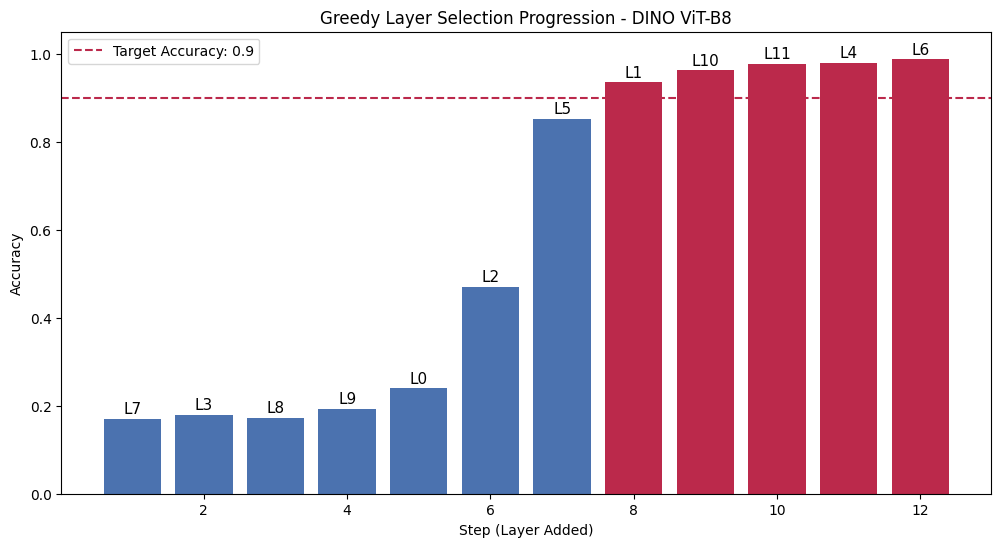

In [47]:
plot_greedy_progression(result_B8, model_name="DINO ViT-B8")

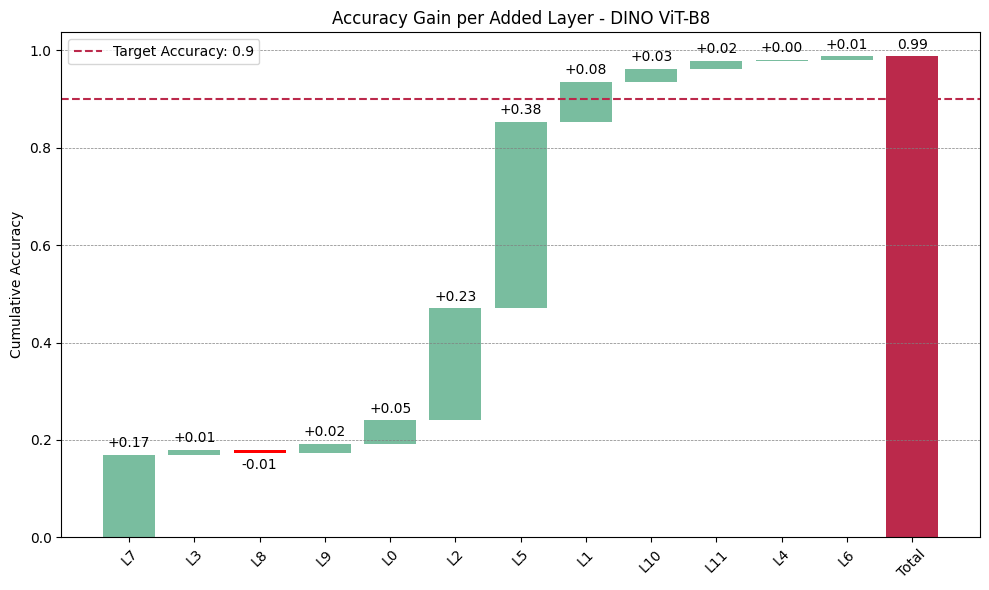

In [78]:
plot_layer_gain_waterfall(result_B8, model_name="DINO ViT-B8")

In DINO ViT-B8, we initially observe no significant improvement in accuracy as the early layers are added—in fact, there is even a temporary drop in performance. However, in the middle phase of the selection process, the model exhibits a noticeable accuracy boost, particularly after adding layers 2 and 5. Ultimately, the model reaches the target threshold of 0.9 after the 8th selected layer, matching the point at which DINO ViT-S16 also achieves the target, while slightly surpassing it in final accuracy. In terms of the selection pattern, the model appears to favor later layers early in the process, with layers 7, 8, and 9 being among the first selected.

## Comparison DINO ViT-B8 vs DINO ViT-B8

In [53]:
def compare_models_progression(result1, result2, name1="DINO ViT-S16", name2="DINO ViT-B8"):
    import matplotlib.pyplot as plt

    x1 = list(range(1, len(result1['accuracy_per_step']) + 1))
    x2 = list(range(1, len(result2['accuracy_per_step']) + 1))

    plt.figure(figsize=(12, 6))
    plt.plot(x1, result1['accuracy_per_step'], marker='o', label=name1)
    plt.plot(x2, result2['accuracy_per_step'], marker='s', label=name2)

    plt.axhline(y=result1['target_acc'], color='gray', linestyle='--', label='Target Accuracy')
    plt.xlabel("Number of Layers Added")
    plt.ylabel("Accuracy")
    plt.title("Comparison of Layer-wise Accuracy Growth")
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 1.05)
    plt.show()


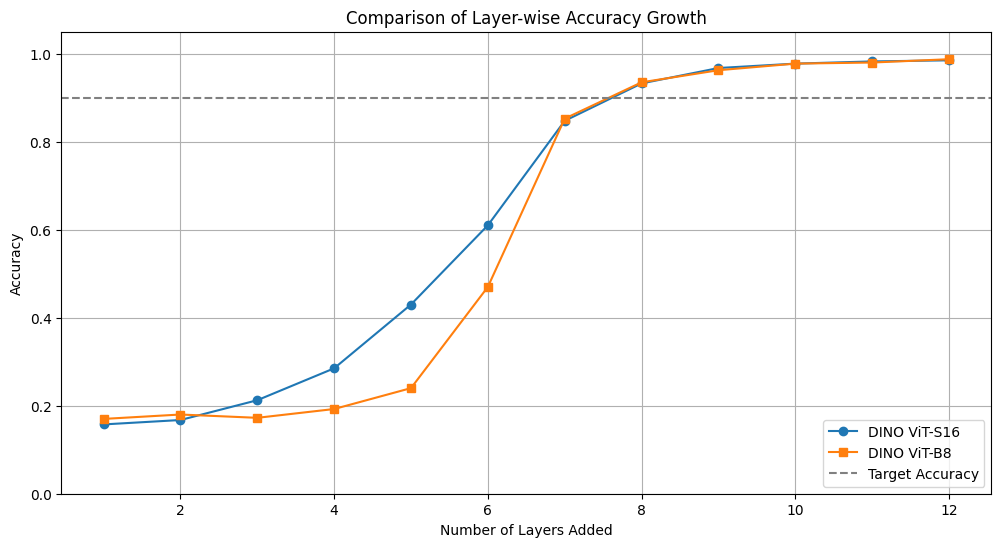

In [54]:
compare_models_progression(result_S16, result_B8, name1="DINO ViT-S16", name2="DINO ViT-B8")

In [73]:
def compare_layer_selection_order(result1, result2, name1="DINO ViT-S16", name2="DINO ViT-B8"):
    import matplotlib.pyplot as plt

    layers1 = result1['added_layers']
    layers2 = result2['added_layers']

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.scatter(range(len(layers1)), layers1, marker='o', s=150, label=name1, color='steelblue')
    ax.scatter(range(len(layers2)), layers2, marker='s', s=150, label=name2, color='darkorange')

    ax.set_xlabel("Selection Step")
    ax.set_ylabel("Layer Index")
    ax.set_title("Order of Selected Layers per Model")
    ax.set_yticks(sorted(set(layers1 + layers2)))
    ax.set_xticks(range(max(len(layers1), len(layers2))))
    ax.invert_yaxis()

    ax.grid(axis='y', linestyle='--', color='gray', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()


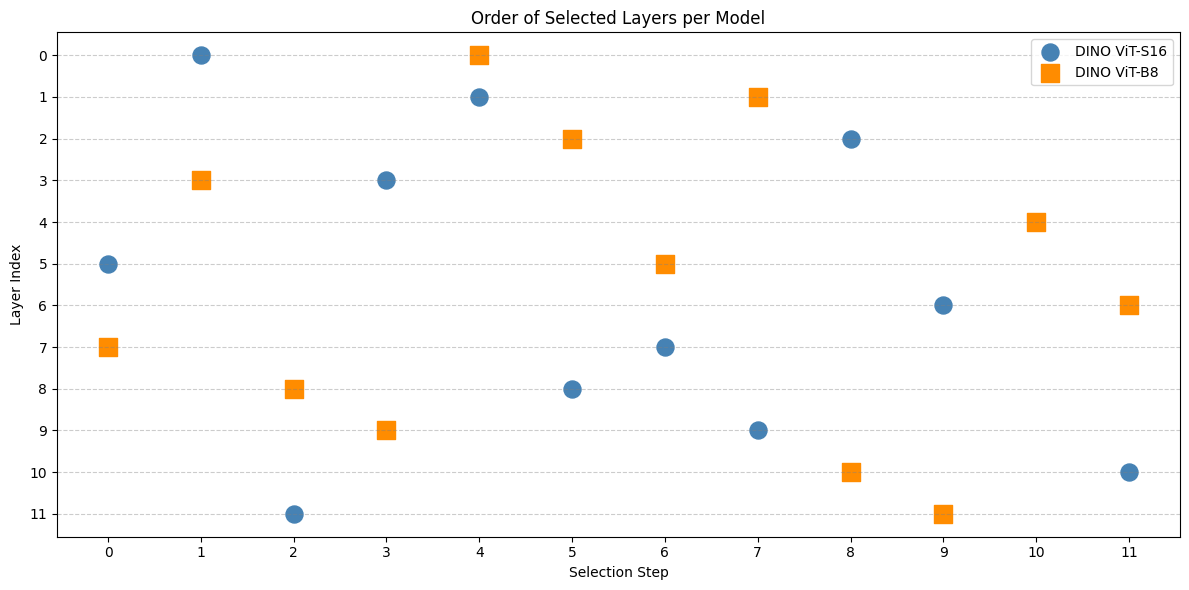

In [74]:
compare_layer_selection_order(result_S16, result_B8, name1="DINO ViT-S16", name2="DINO ViT-B8")

In [75]:
def plot_layer_selection_heatmap(result1, result2, name1="ViT-S16", name2="ViT-B8"):
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns

    max_layers = max(max(result1['added_layers']), max(result2['added_layers'])) + 1
    steps = max(len(result1['added_layers']), len(result2['added_layers']))

    def build_matrix(added_layers, total_layers, total_steps):
        matrix = np.zeros((total_layers, total_steps))
        annot = np.full((total_layers, total_steps), "", dtype=object)
        for step, layer in enumerate(added_layers):
            matrix[layer, step] = 1
            annot[layer, step] = f"{layer}"
        return matrix, annot

    mat1, annot1 = build_matrix(result1['added_layers'], max_layers, steps)
    mat2, annot2 = build_matrix(result2['added_layers'], max_layers, steps)

    fig, axes = plt.subplots(1, 2, figsize=(14, max_layers * 0.5), sharey=True)

    sns.heatmap(mat1, cmap="Greens", cbar=False, annot=annot1, fmt="", 
                linewidths=0.5, linecolor='lightgrey', ax=axes[0])
    axes[0].set_title(f"{name1} Layer Selection Steps")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Layer")

    sns.heatmap(mat2, cmap="Oranges", cbar=False, annot=annot2, fmt="", 
                linewidths=0.5, linecolor='lightgrey', ax=axes[1])
    axes[1].set_title(f"{name2} Layer Selection Steps")
    axes[1].set_xlabel("Step")

    plt.tight_layout()
    plt.show()


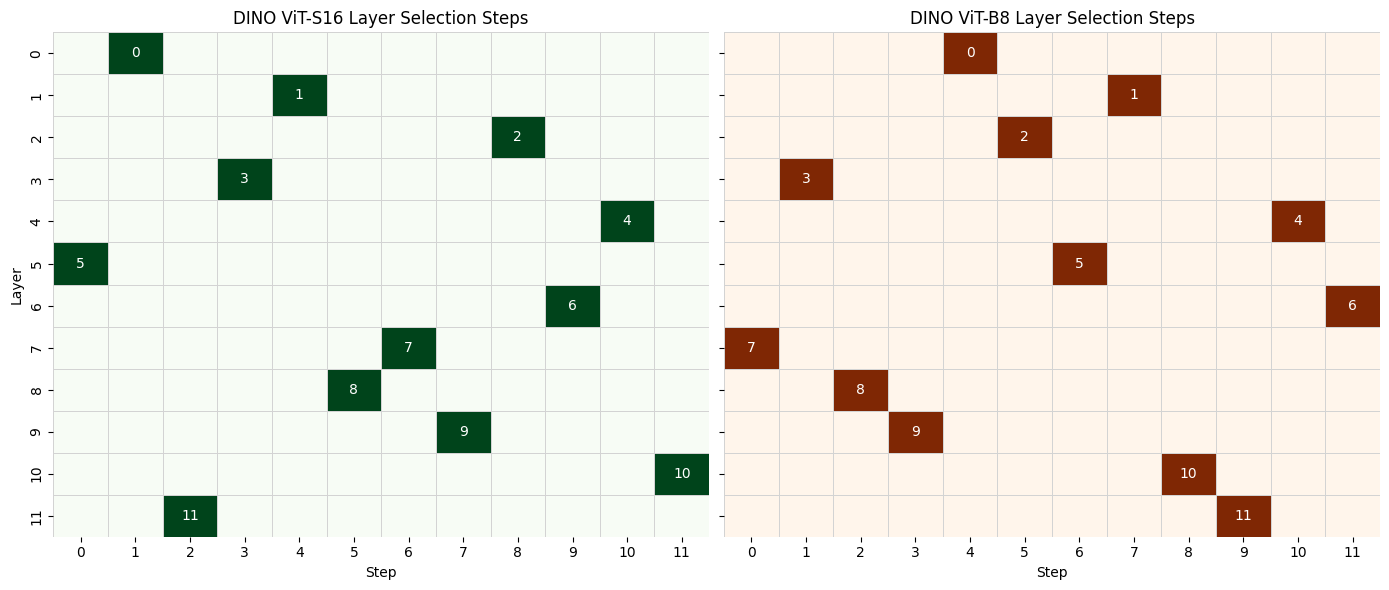

In [76]:
plot_layer_selection_heatmap(result_S16, result_B8, name1="DINO ViT-S16", name2="DINO ViT-B8")